# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv(r"C:\Users\User\Desktop\DATA LOVES ACADEMY\DATA\yulu_rental.csv")

In [2]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [14]:
print(f"Маємо в наборі наступну загальну кількість даних: {df.size}")
print(f'Рядків: {df.shape[0]}, Колонок: {df.shape[1]}')

Маємо в наборі наступну загальну кількість даних: 206834
Рядків: 10886, Колонок: 19


In [12]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


In [29]:
print(f"Наші дані охополюють період від: {df.date.min()} до: {df.date.max()}")
diff_time = df.index.diff().dropna().value_counts()
print(f"Рівень деталізації цих даних переважно погодинний, оскільки найбільше зустрічається різниця між сусідніми записами: {diff_time.head(1)}")

Наші дані охополюють період від: 2011-01-01 до: 2012-12-19
Рівень деталізації цих даних переважно погодинний, оскільки найбільше зустрічається різниця між сусідніми записами: datetime
0 days 01:00:00    10820
Name: count, dtype: int64


## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


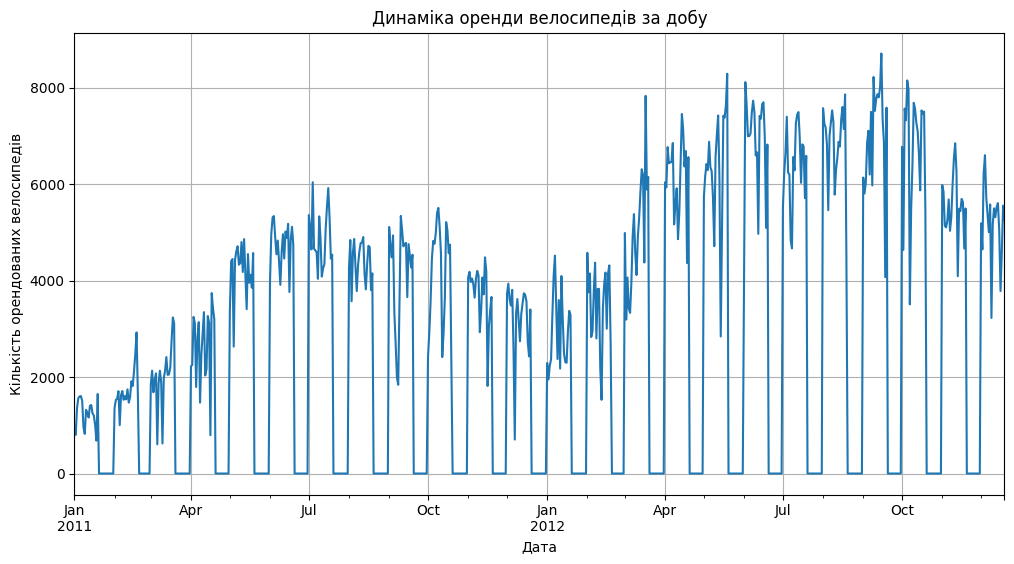

In [38]:
day_rent = df['count'].resample('D').sum()
day_rent.plot(
    figsize=(12, 6),
    title='Динаміка оренди велосипедів за добу'
)

plt.xlabel('Дата')
plt.ylabel('Кількість орендованих велосипедів')
plt.grid(True)
plt.show()

1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
    Відсутність даних за певний проміжок часу.

2. Які загальні тенденції ви бачите на графіку?
    Від року до року бачимо зростання кількості оренд.

3. Чи помітні якісь сезонні коливання?
    В межах кожного року є тенденція на збільшення оренд в теплий період.

4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?
    Так, ми бачимо періоди з максимальними значенням вище 8000. Причиною може бути хороша погода, вихідні/святкові дні, можливо якісь заходи пов'язані саме з велоспортом.
    Мінімально низькі значення (виключаємо ті, що 0) скоріше за все обумовленні низьким сезоном, поганими погодними умовами.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

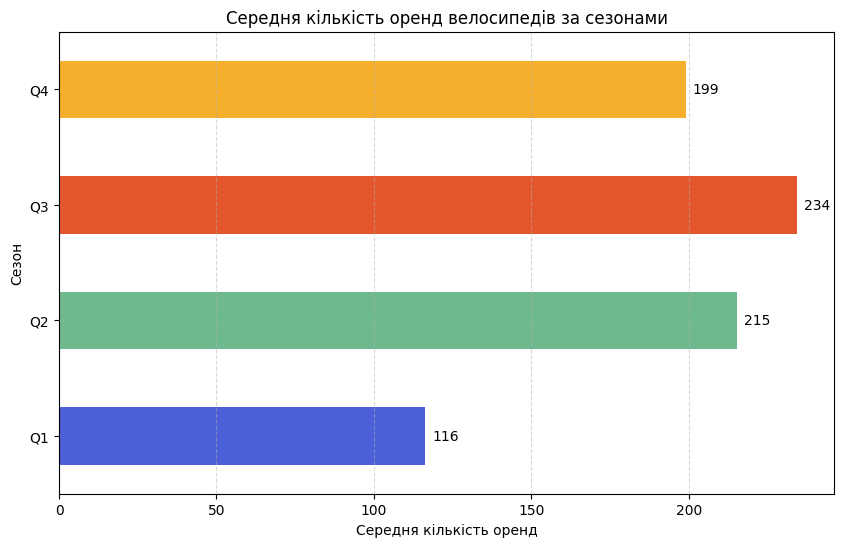

In [71]:

season_avg = df.groupby('season')['count'].mean()

season_names = {
    1: 'Q1',
    2: 'Q2',
    3: 'Q3',
    4: 'Q4'
}

season_avg.index = season_avg.index.map(season_names)

ax = season_avg.plot(
    kind='barh',
    figsize=(10, 6),
    color=['#4B60D7', '#6FB98F','#E4572E', '#F6AE2D'],
    title='Середня кількість оренд велосипедів за сезонами'
)

ax.set_xlabel('Середня кількість оренд')
ax.set_ylabel('Сезон')
ax.grid(axis='x', linestyle='--', alpha=0.5)

for bar in ax.patches:
    width = bar.get_width()
    ax.annotate(
        f'{width:.0f}',
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords='offset points',
        ha='left',
        va='center',
        fontsize=10
    )

plt.show()

1. В який квартал найбільша середня кількість оренди велосипедів?

    В третьому кварталі найбільша середня кількість оренди велосипедів.

2. Як ви можете пояснити таку сезонну закономірність?

    Тепла і комфортна погода

3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

    У два рази (243/116=2,02)

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


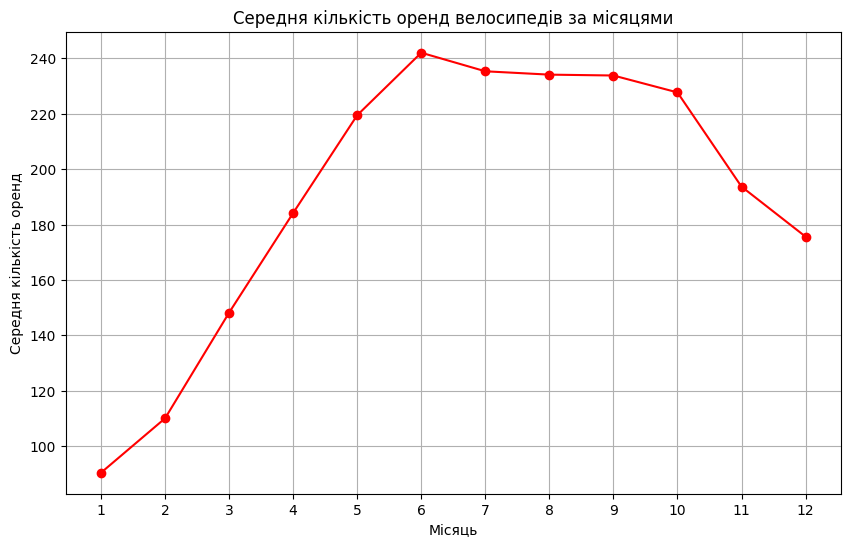

In [70]:
monthly_rent = df.groupby('month')['count'].mean()

ax = monthly_rent.plot(
    kind='line',
    marker='o',
    color='red',
    figsize=(10, 6),
    title='Середня кількість оренд велосипедів за місяцями',
    xlabel='Місяць',
    ylabel='Середня кількість оренд',
    grid=True
)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(range(1, 13))

plt.show()


1. В які місяці спостерігається пік та спад оренди?

    Пік припадає на червень місяць (кінець 2 кварталу). Найбільший спад у січні.

2. Чи збігається ця закономірність з результатами з попереднього завдання?

    Далі високий попит тримається весь 3-й квартал і перший місяць 4-го кварталу. Ці дані збігаються з даними з попереднього завдання.


3. Як може вплинути клімат на оренду велосипедів протягом року?

    Клімат впливає дуже сильно на цей бізнес. Кращий клімат - більше оренд, гірший - менше.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

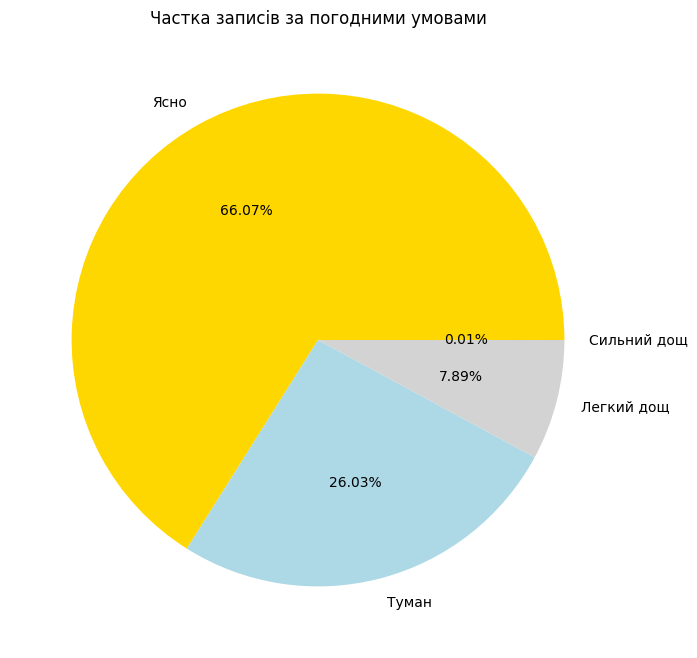

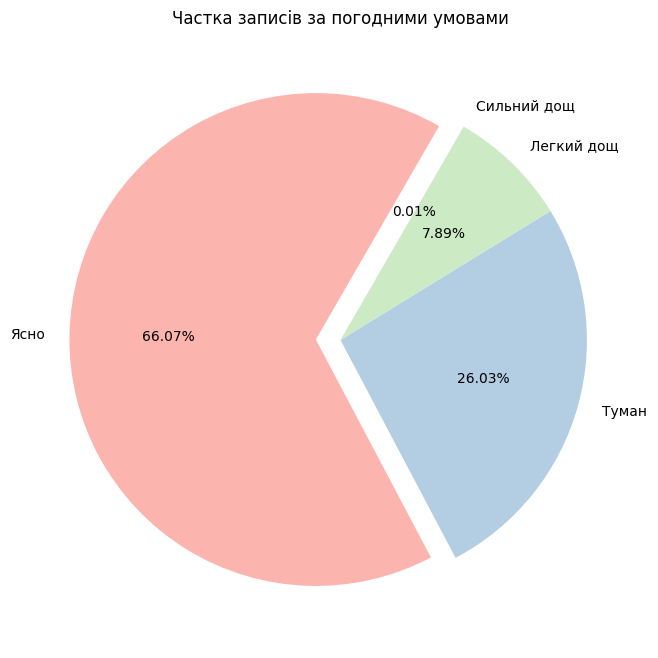

In [95]:
forecast_data = df['weather'].value_counts()

forecast_data.plot.pie(
    figsize=(8, 8),
    autopct='%1.2f%%',
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    title='Частка записів за погодними умовами',
    explode=[0.1, 0, 0, 0],
    startangle=60,
    #shadow=True,
    colors=plt.cm.Pastel1.colors
);


1. Яка погода переважає в датасеті?

    В датасеті переважає ясна погода.

2. Чи є дні із сильним дощем? Яка їх частка?

    Так, є. їх частка 0,01%

3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

    На мою думку погодні умови прямо впливають на попит на оренду велосипедів але за певного температурного режиму - взимку, при -30 градусів у сонячний день небагато бажаючих їздити на велосипеді.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

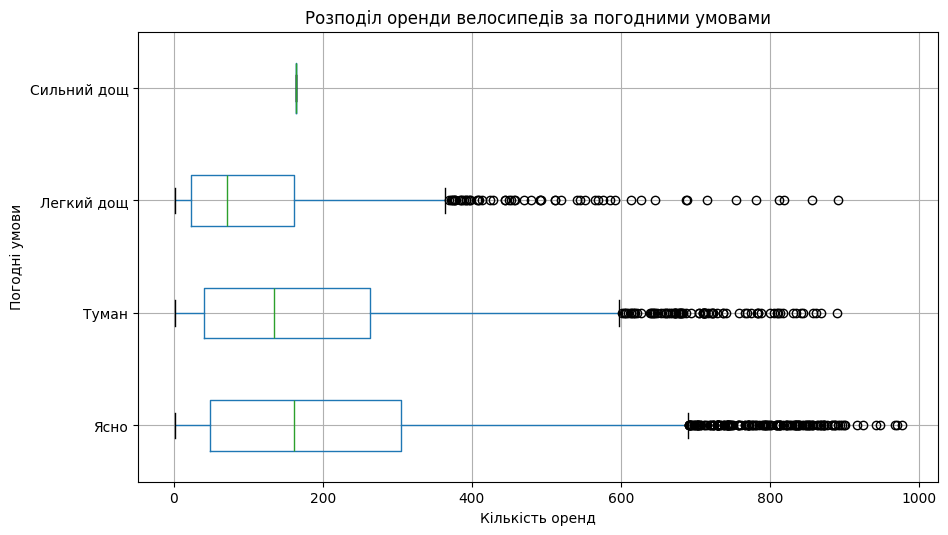

In [106]:
ax = df.boxplot(
    column='count',
    by='weather',
    figsize=(10, 6),
    vert=False,
    grid=True
)

plt.title('Розподіл оренди велосипедів за погодними умовами')
plt.suptitle('')
plt.xlabel('Кількість оренд')
plt.ylabel('Погодні умови')

weather_labels = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']

ax.set_yticklabels(weather_labels);


1. При якій погоді найбільший розкид у кількості оренди?

    Найбільший розкид видно при погоді Ясно. Має найширший бокс


2. Чи є викиди (outliers) в даних? При якій погоді?

    Так, викиди є. Їх помітно при погоді ясно, туман, легкий дощ. Саме там багато кружечків за вусами.


3. При якій погоді медіанне значення оренди найвище?

    Найвище медіанне значення при погоді ясно.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

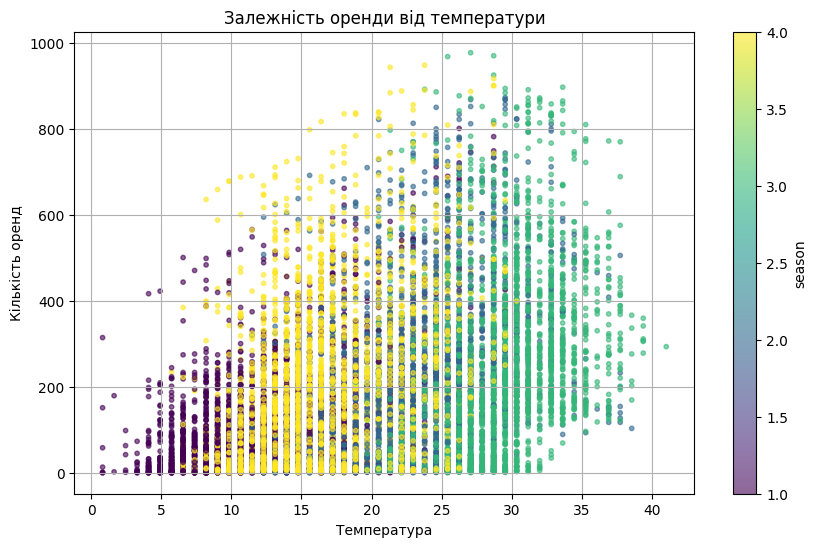

In [114]:
df.plot.scatter(
    x='temp',
    y='count',
    c='season',
    colormap='viridis',
    title='Залежність оренди від температури',
    figsize=(10, 6),
    s=10,
    alpha=0.6
);

plt.xlabel('Температура')
plt.ylabel('Кількість оренд')
plt.grid(True)

Між температурою та кількістю оренд велосипедів спостерігається позитивний зв'язок. Зі зростанням температури кількість оренд збільшується. Найбільша активність спостерігається при температурі приблизно 20–30 градусів. При дуже низьких або дуже високих температурах кількість оренд зменшується.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

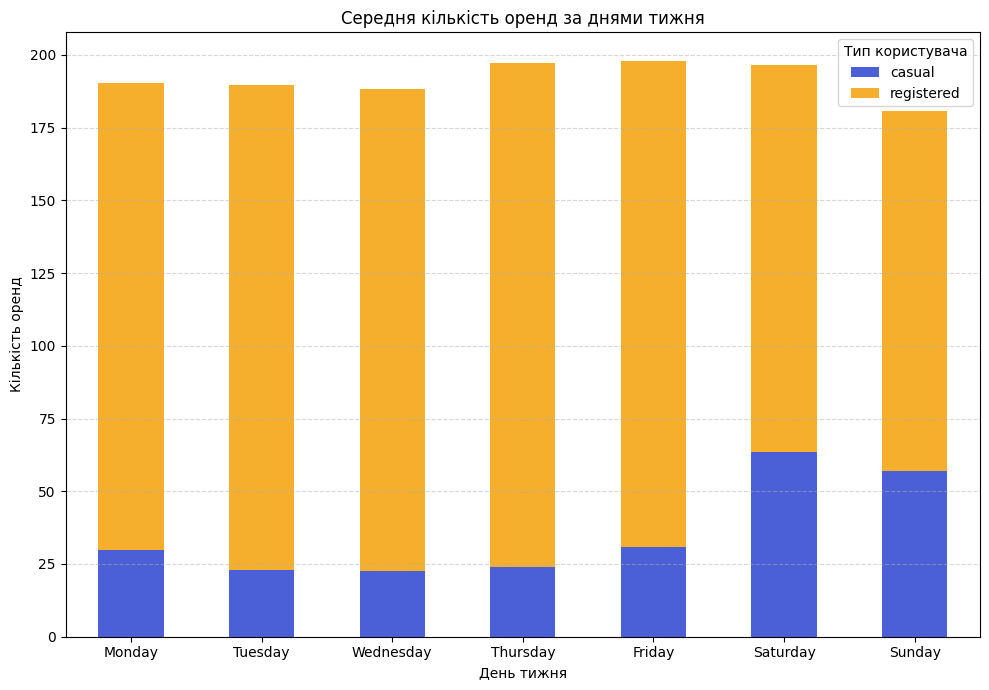

In [132]:
weekly_users = df.groupby('weekday_num')[['casual', 'registered']].mean()

weekly_users.index = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

ax = weekly_users.plot(
    kind='bar',
    stacked=True,
    figsize=(10,7),
    color=['#4B60D7', '#F6AE2D'],
    title='Середня кількість оренд за днями тижня'
)

ax.set_xlabel('День тижня')
ax.set_ylabel('Кількість оренд')

plt.legend(title='Тип користувача', loc=1)
plt.xticks(rotation = 0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

1. В які дні тижня більше оренд від зареєстрованих користувачів?

    На графіку видно, що зареєстровані користувачі значно активніші у будні дні.


2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

    Випадкові користувачі частіше користуються сервісом у вихідні дні, що може бути пов’язано з відпочинком або туризмом.